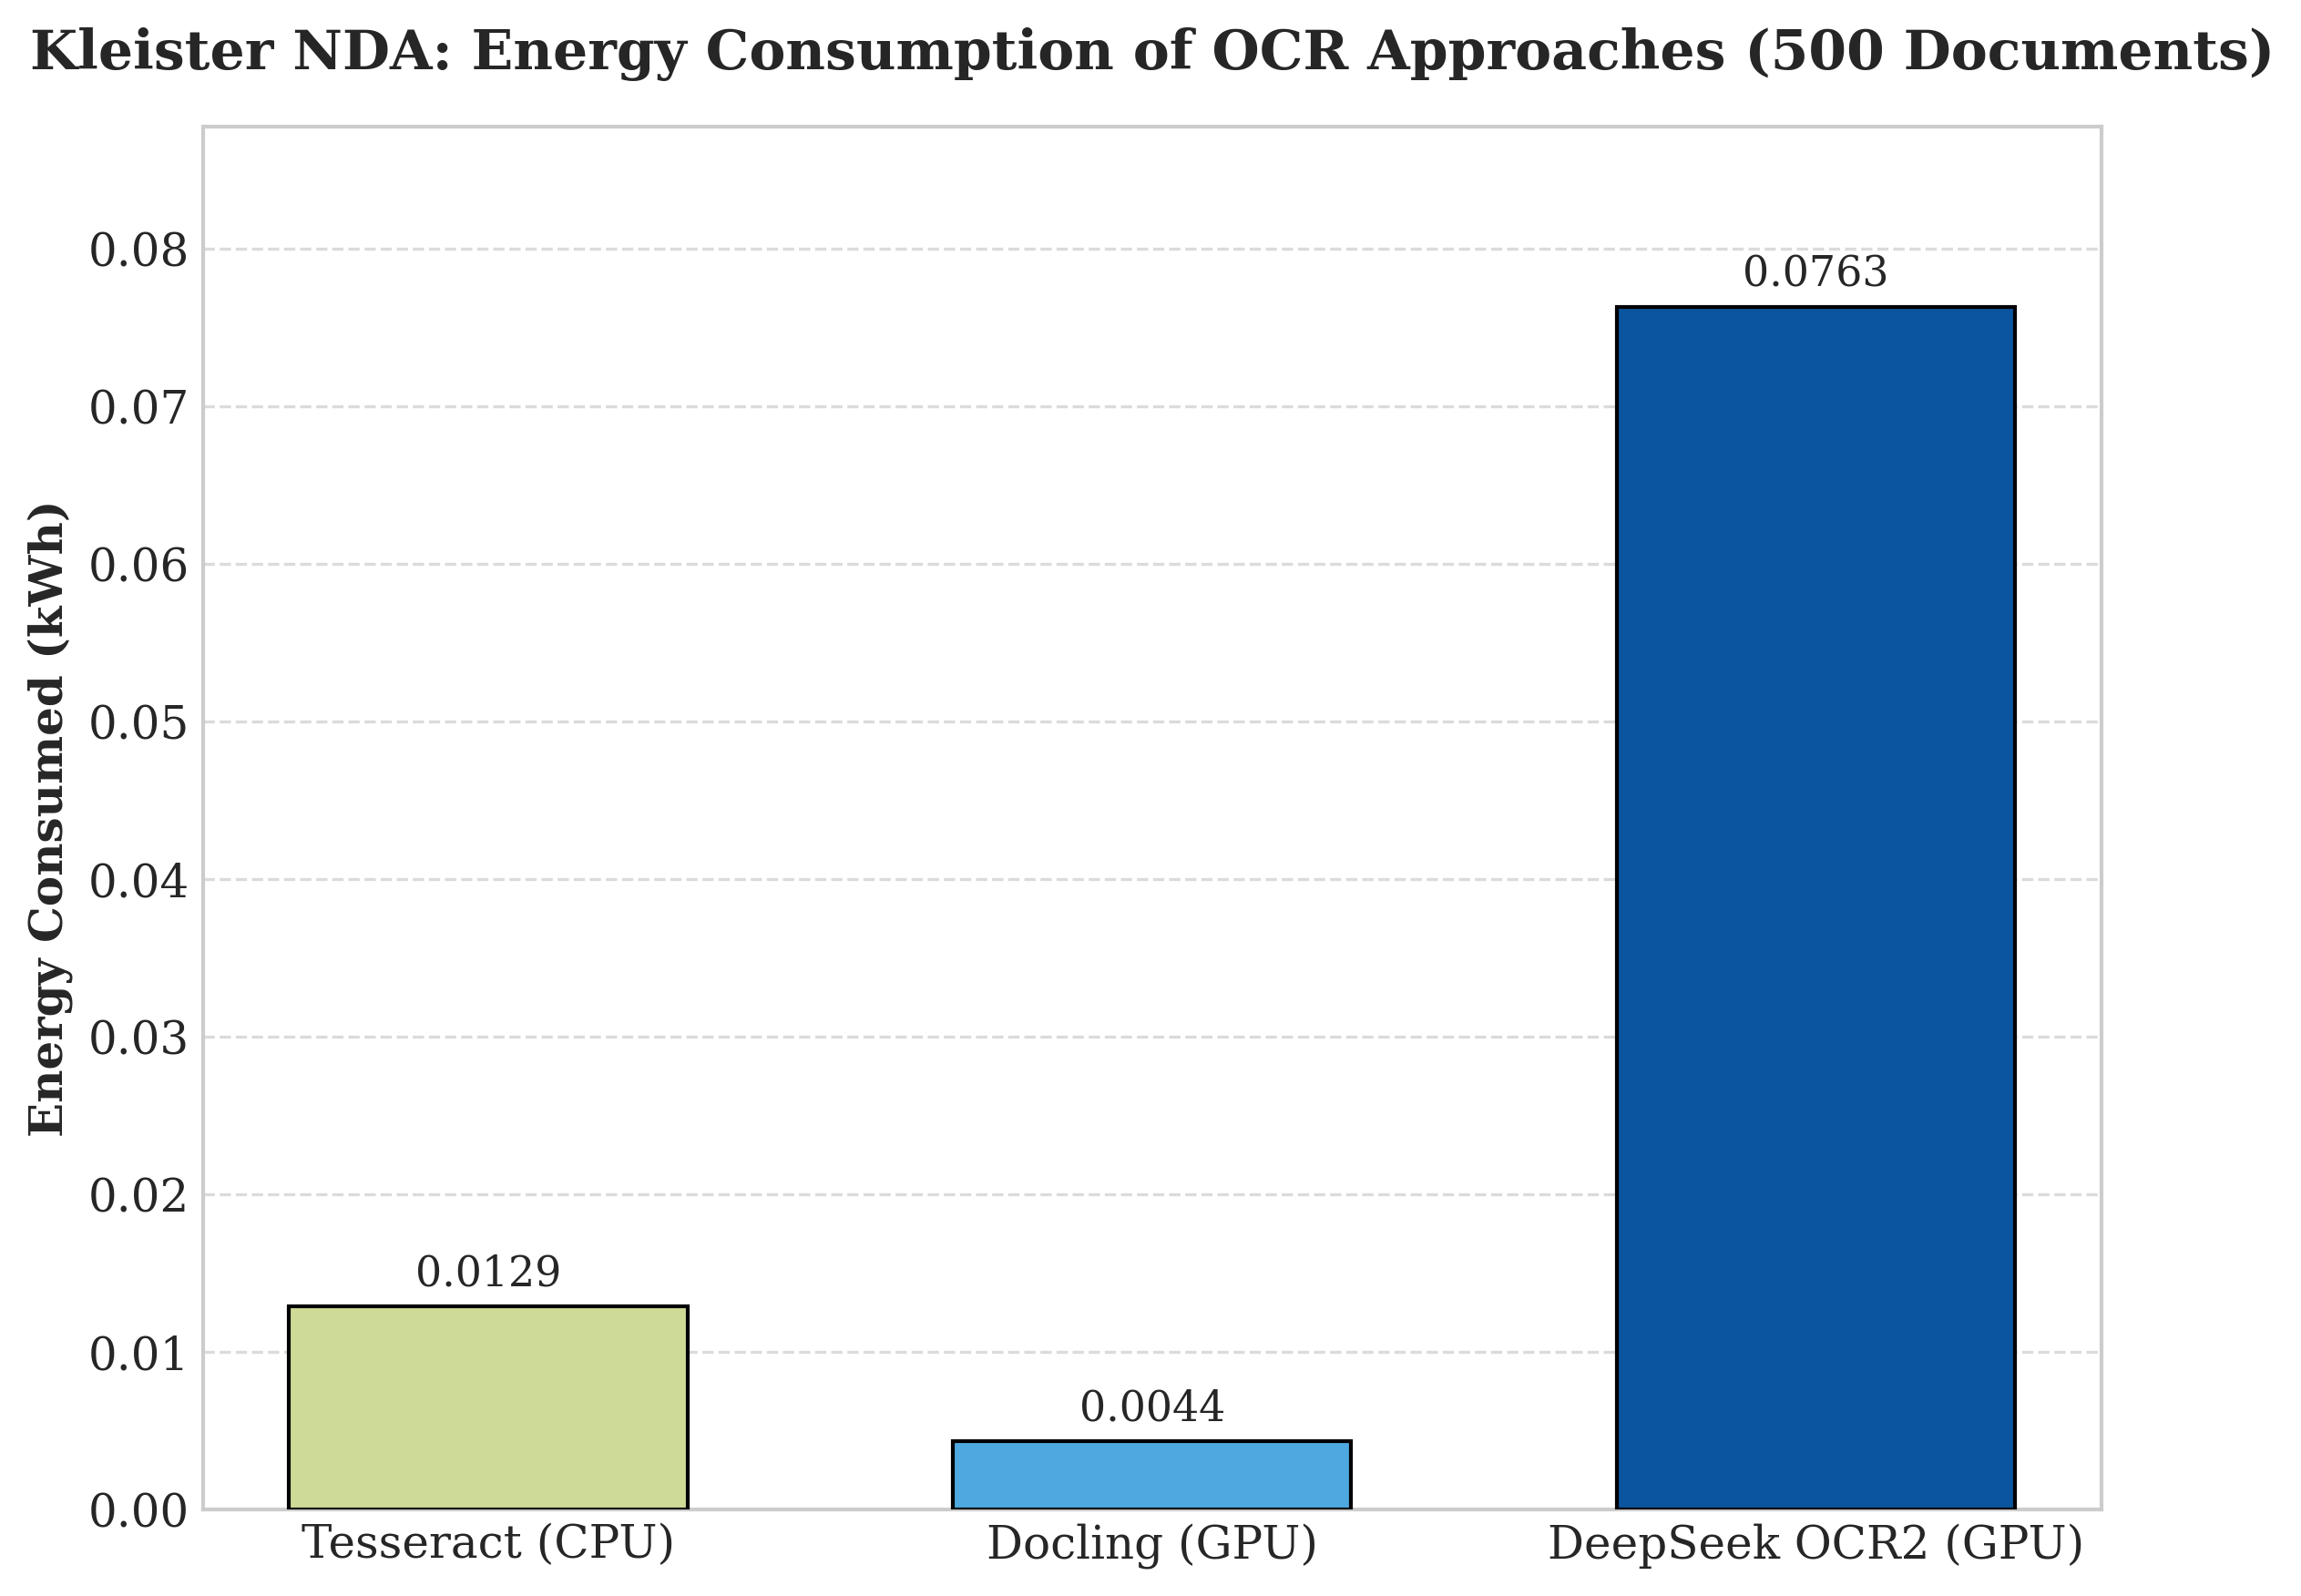

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Read the data
df_tess = pd.read_csv('tesseract_kleister.csv')
df_docl = pd.read_csv('docling_kleister.csv')
df_deep = pd.read_csv('deepseek_kleister.csv')

# 2. Extract values and normalize to kWh
energy_tesseract = float(df_tess[df_tess['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0])
energy_docling = float(df_docl[df_docl['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0])

# DeepSeek is recorded in Wh, so we divide by 1000 to get kWh
# We also normalize it to 500 documents since the original run was on 540 queries
num_queries_deepseek = float(df_deep['num_queries'].values[0])
energy_deepseek = (float(df_deep['total_energy_wh'].values[0]) / 1000.0) * (500.0 / num_queries_deepseek)

# 3. Setup data for plotting
methods = ['Tesseract (CPU)', 'Docling (GPU)', 'DeepSeek OCR2 (GPU)']
energies = [energy_tesseract, energy_docling, energy_deepseek]

# Standard colors following your previous palette
ocr_colors = {
    'Tesseract (CPU)': '#cedb97',  # Baseline
    'Docling (GPU)': '#4da9df',  # Docling
    'DeepSeek OCR2 (GPU)': '#0b559f'  # DeepSeek
}

# 4. Plotting Setup
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'figure.figsize': (8.0, 6.0),
    'figure.dpi': 300
})

fig, ax = plt.subplots()

# Determine bar positions
x = np.arange(len(methods))
width = 0.6

# 5. Plot each OCR strategy
for i, method in enumerate(methods):
    color = ocr_colors[method]
    rects = ax.bar(x[i], energies[i], width, label=method, color=color, edgecolor='black', zorder=3)

    # Add value labels on top of the bars
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11)

# 6. Formatting
ax.set_title('Kleister NDA: Energy Consumption of OCR Approaches (500 Documents)', pad=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=0, ha='center')
ax.set_ylabel('Energy Consumed (kWh)', fontweight='bold')

# Scale Y limit slightly higher to leave room for the value annotations
ax.set_ylim(0, max(energies) * 1.15)

ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.grid(False, axis='x')

plt.tight_layout()
plt.savefig('energy_consumption_comparison.pdf', format='pdf', bbox_inches='tight')
plt.savefig('energy_consumption_comparison.png', format='png', bbox_inches='tight')

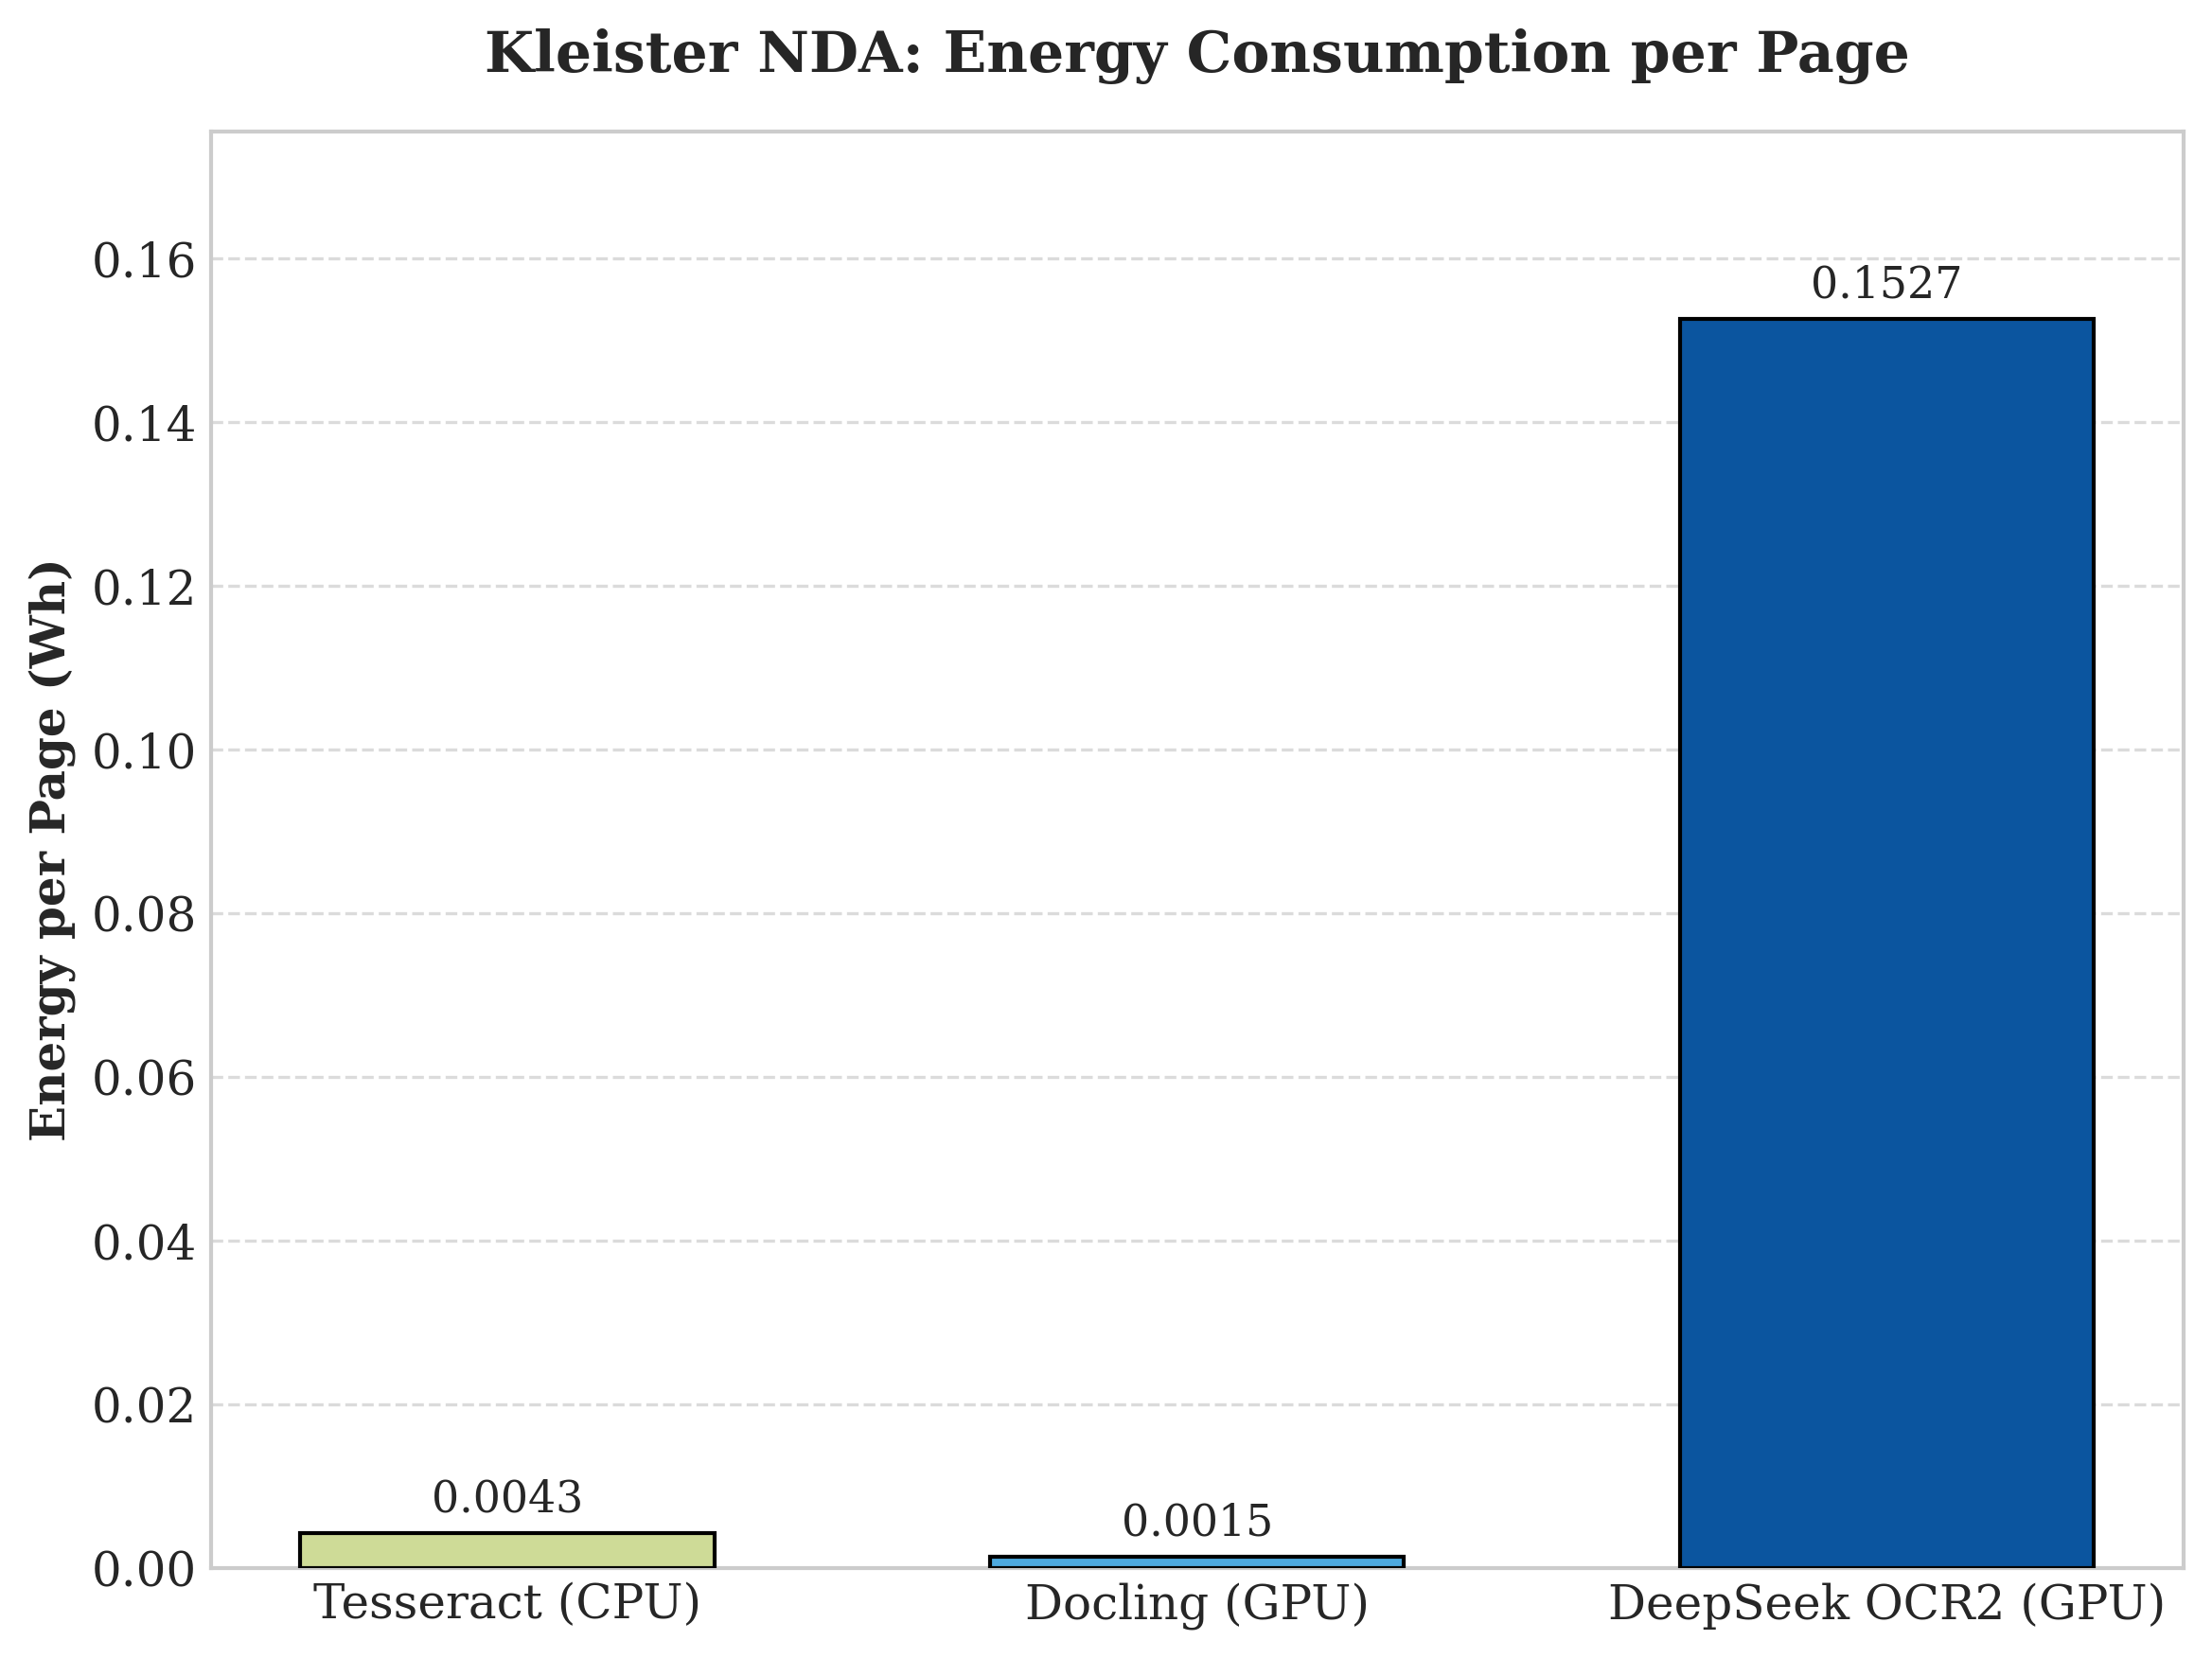

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Read the data
df_tess = pd.read_csv('tesseract_kleister.csv')
df_docl = pd.read_csv('docling_kleister.csv')
df_deep = pd.read_csv('deepseek_kleister.csv')

# 2. Extract values and calculate energy per page (in Wh)
energy_tesseract_kwh = float(df_tess[df_tess['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0])
pages_tesseract = float(df_tess[df_tess['Metric'] == 'Total Pages Processed']['Value'].values[0])
energy_per_page_tesseract = (energy_tesseract_kwh * 1000.0) / pages_tesseract

energy_docling_kwh = float(df_docl[df_docl['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0])
pages_docling = float(df_docl[df_docl['Metric'] == 'Total Pages Processed']['Value'].values[0])
energy_per_page_docling = (energy_docling_kwh * 1000.0) / pages_docling

# For DeepSeek, total_energy_wh is already in Wh. Assume num_queries = number of pages processed.
energy_deepseek_wh = float(df_deep['total_energy_wh'].values[0])
queries_deepseek = float(df_deep['num_queries'].values[0])
energy_per_page_deepseek = energy_deepseek_wh / queries_deepseek

# 3. Setup data for plotting
methods = ['Tesseract (CPU)', 'Docling (GPU)', 'DeepSeek OCR2 (GPU)']
energies_per_page = [energy_per_page_tesseract, energy_per_page_docling, energy_per_page_deepseek]

# Standard colors
ocr_colors = {
    'Tesseract (CPU)': '#cedb97',
    'Docling (GPU)': '#4da9df',
    'DeepSeek OCR2 (GPU)': '#0b559f'
}

# 4. Plotting Setup
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'figure.figsize': (8.0, 6.0),
    'figure.dpi': 300
})

fig, ax = plt.subplots()

x = np.arange(len(methods))
width = 0.6

# 5. Plot each OCR strategy
for i, method in enumerate(methods):
    color = ocr_colors[method]
    rects = ax.bar(x[i], energies_per_page[i], width, label=method, color=color, edgecolor='black', zorder=3)

    for rect in rects:
        height = rect.get_height()
        if height > 0:
            # Format to 4 decimal places for clarity
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11)

# 6. Formatting
ax.set_title('Kleister NDA: Energy Consumption per Page', pad=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=0, ha='center')
ax.set_ylabel('Energy per Page (Wh)', fontweight='bold')

# Scale Y limit slightly higher to leave room for the annotations
ax.set_ylim(0, max(energies_per_page) * 1.15)

ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.grid(False, axis='x')

plt.tight_layout()
plt.savefig('energy_per_page_comparison.pdf', format='pdf', bbox_inches='tight')
plt.savefig('energy_per_page_comparison.png', format='png', bbox_inches='tight')